In [1]:
import pandas as pd

df = pd.read_csv("synthetic_saas_churn_dataset.csv")
df.head()

,account_id,segment,subscription_type,plan_tier,tenure_months,mrr,bundles_contracted,extra_users,renewal_due_days,subscription_status,...,csm_meetings_last_quarter,strategic_review_done,success_plan_active,tickets_last_quarter,reopened_tickets,avg_resolution_days,csat_support,sentiment_csm,sentiment_support,churn_label
0,ACC_00001,SMB,monthly,Pro,4,54.84,1,1,164,active,...,2,0,1,5,1,6.7,3.5,-0.02,-0.14,0
1,ACC_00002,Enterprise,monthly,Enterprise,39,9793.65,4,12,51,churned,...,2,0,0,2,0,3.1,4.0,0.28,0.30,0
2,ACC_00003,Mid-Market,annual,Business,7,1805.48,2,4,74,churned,...,0,0,1,4,1,7.4,3.7,-0.28,0.18,0
3,ACC_00004,SMB,monthly,Pro,33,156.14,1,1,91,churned,...,0,0,1,4,0,6.2,2.9,-0.16,-0.36,1
4,ACC_00005,SMB,annual,Guru,5,334.60,1,0,61,churned,...,0,0,1,6,1,4.2,3.5,-0.26,-0.45,0


In [2]:
df["churn_probability"].describe()

KeyError: 'churn_probability'

In [3]:
import pandas as pd
import joblib

In [4]:
df = pd.read_csv("synthetic_saas_churn_dataset.csv")
model = joblib.load("best_churn_model.pkl")

print(df.shape)
print(df.columns.tolist())

(2500, 30)
['account_id', 'segment', 'subscription_type', 'plan_tier', 'tenure_months', 'mrr', 'bundles_contracted', 'extra_users', 'renewal_due_days', 'subscription_status', 'renewed_last_quarter', 'renewal_intent', 'in_grace_period', 'login_count_30d', 'tool_activity_score', 'usage_change_vs_prev_quarter', 'feature_adoption_score', 'key_reports_used_30d', 'days_since_last_login', 'emails_with_csm_30d', 'csm_meetings_last_quarter', 'strategic_review_done', 'success_plan_active', 'tickets_last_quarter', 'reopened_tickets', 'avg_resolution_days', 'csat_support', 'sentiment_csm', 'sentiment_support', 'churn_label']


In [5]:
import pandas as pd
import joblib

In [6]:
df = pd.read_csv("synthetic_saas_churn_dataset.csv")
model = joblib.load("best_churn_model.pkl")

print(df.shape)
df.head()

(2500, 30)


,account_id,segment,subscription_type,plan_tier,tenure_months,mrr,bundles_contracted,extra_users,renewal_due_days,subscription_status,...,csm_meetings_last_quarter,strategic_review_done,success_plan_active,tickets_last_quarter,reopened_tickets,avg_resolution_days,csat_support,sentiment_csm,sentiment_support,churn_label
0,ACC_00001,SMB,monthly,Pro,4,54.84,1,1,164,active,...,2,0,1,5,1,6.7,3.5,-0.02,-0.14,0
1,ACC_00002,Enterprise,monthly,Enterprise,39,9793.65,4,12,51,churned,...,2,0,0,2,0,3.1,4.0,0.28,0.30,0
2,ACC_00003,Mid-Market,annual,Business,7,1805.48,2,4,74,churned,...,0,0,1,4,1,7.4,3.7,-0.28,0.18,0
3,ACC_00004,SMB,monthly,Pro,33,156.14,1,1,91,churned,...,0,0,1,4,0,6.2,2.9,-0.16,-0.36,1
4,ACC_00005,SMB,annual,Guru,5,334.60,1,0,61,churned,...,0,0,1,6,1,4.2,3.5,-0.26,-0.45,0


In [7]:
import pandas as pd
import joblib

In [8]:
df = pd.read_csv("synthetic_saas_churn_dataset.csv")
model = joblib.load("best_churn_model.pkl")

print(df.shape)
df.head()

(2500, 30)


,account_id,segment,subscription_type,plan_tier,tenure_months,mrr,bundles_contracted,extra_users,renewal_due_days,subscription_status,...,csm_meetings_last_quarter,strategic_review_done,success_plan_active,tickets_last_quarter,reopened_tickets,avg_resolution_days,csat_support,sentiment_csm,sentiment_support,churn_label
0,ACC_00001,SMB,monthly,Pro,4,54.84,1,1,164,active,...,2,0,1,5,1,6.7,3.5,-0.02,-0.14,0
1,ACC_00002,Enterprise,monthly,Enterprise,39,9793.65,4,12,51,churned,...,2,0,0,2,0,3.1,4.0,0.28,0.30,0
2,ACC_00003,Mid-Market,annual,Business,7,1805.48,2,4,74,churned,...,0,0,1,4,1,7.4,3.7,-0.28,0.18,0
3,ACC_00004,SMB,monthly,Pro,33,156.14,1,1,91,churned,...,0,0,1,4,0,6.2,2.9,-0.16,-0.36,1
4,ACC_00005,SMB,annual,Guru,5,334.60,1,0,61,churned,...,0,0,1,6,1,4.2,3.5,-0.26,-0.45,0


In [9]:
feature_cols = [c for c in df.columns if c not in ["account_id", "churn_label"]]
X = df[feature_cols].copy()

df["churn_probability"] = model.predict_proba(X)[:, 1]
df[["account_id", "churn_probability"]].head()

,account_id,churn_probability
0,ACC_00001,0.000008
1,ACC_00002,0.003568
2,ACC_00003,0.007042
3,ACC_00004,0.987312
4,ACC_00005,0.022438


In [10]:
df["churn_probability"].describe()

count    2.500000e+03
mean     3.223921e-01
std      4.569537e-01
min      3.802388e-07
25%      2.896415e-03
50%      8.219086e-03
75%      9.809744e-01
max      9.965668e-01
Name: churn_probability, dtype: float64

<Axes: >

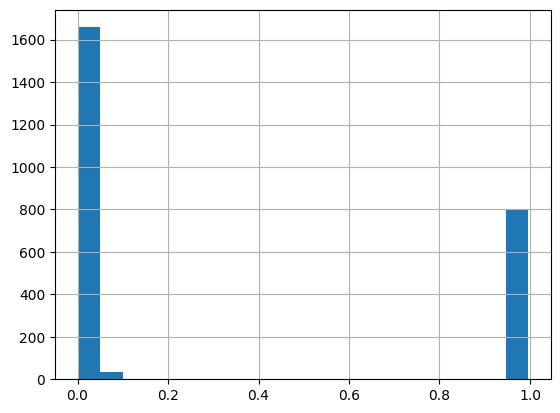

In [11]:
df["churn_probability"].hist(bins=20)

In [12]:
df[(df["churn_probability"] >= 0.10) & (df["churn_probability"] < 0.85)][
    ["account_id", "churn_probability"]
].head(20)

,account_id,churn_probability
2096,ACC_02097,0.119104
2190,ACC_02191,0.129006


In [13]:
def risk_level_test(prob):
    if prob >= 0.85:
        return "High"
    elif prob >= 0.10:
        return "Medium"
    return "Low"

df["risk_level_test"] = df["churn_probability"].apply(risk_level_test)
df["risk_level_test"].value_counts()

risk_level_test
Low       1692
High       806
Medium       2
Name: count, dtype: int64